# Weather Data Analysis

## Executive Summary
This project analyzes historical weather data to understand patterns in temperature, humidity, wind speed, and atmospheric pressure.

The analysis reveals strong seasonal patterns in temperature across the dataset. Monthly analysis shows that June is the hottest month, while January is the coldest month, with a temperature difference of approximately 20.42°C between the two extremes.

The rolling average analysis highlights repeating yearly temperature cycles, where temperatures increase toward the middle of the year and decline toward the beginning and end of the year.

Correlation analysis shows important relationships between weather variables. In particular, temperature has a strong negative relationship with atmospheric pressure and a moderate negative relationship with humidity.

Extreme weather detection also identifies unusual temperature events, helping highlight potential climate anomalies.

Overall, the analysis provides useful insights into seasonal climate behavior and weather variable relationships. These findings can support environmental monitoring, climate studies, and future weather forecasting models.

## Objective

The objective of this project is to analyze historical weather data to understand patterns in temperature, humidity, wind speed, and atmospheric pressure.

Through statistical analysis and visualizations, this study aims to identify trends, relationships between weather variables, and seasonal climate patterns.

Understanding these patterns helps in environmental monitoring, climate research, and weather forecasting.

## Business Questions 
1. What are the overall temperature trends observed in the dataset?

2. How does humidity influence temperature levels?

3. What is the relationship between wind speed and different weather conditions?

4. Which weather conditions occur most frequently in the dataset?

5. Is there a correlation between major weather variables such as temperature, humidity, and wind speed?

## Tools and Technologies Used

The following tools were used to analyze the weather dataset:

- Python
- Pandas for data analysis
- NumPy for numerical computations
- Matplotlib for visualization
- Seaborn for statistical graphics
- Jupyter Notebook

## Dataset Source and Columns

The dataset used for this project is the **Weather Dataset**, which contains meteorological measurements used for climate and weather analysis.

Source: Kaggle – Weather Dataset

The dataset includes the following columns:

- Date – Observation date
- Temperature – Recorded temperature
- Humidity – Percentage of atmospheric moisture
- Wind Speed – Speed of wind
- Precipitation – Amount of rainfall
- Weather Condition – General weather description

In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

In [2]:
# 2. Load Dataset
df = pd.read_csv("DailyDelhiClimateTrain.csv")
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:\n", df.head())

Dataset Shape: (1462, 5)

First 5 Rows:
          date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000


In [3]:
# 3. Data Validation & Cleaning
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nMissing Values:\n", df.isnull().sum())

print("\nPressure Range Check:")
print("Min Pressure:", df["meanpressure"].min())
print("Max Pressure:", df["meanpressure"].max())


Duplicate Rows: 0

Missing Values:
 date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

Pressure Range Check:
Min Pressure: -3.0416666666666665
Max Pressure: 7679.333333333333


In [4]:
# 4. Data Cleaning
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

# Remove unrealistic atmospheric pressure values
df = df[(df["meanpressure"] > 900) & (df["meanpressure"] < 1100)]

print("\nDataset Shape After Cleaning:", df.shape)


Dataset Shape After Cleaning: (1455, 5)


In [5]:
# 4. Feature Engineering
df["Year"] = df["date"].dt.year
df["Month"] = df["date"].dt.month
df["Month_Name"] = df["date"].dt.month_name()

In [6]:
# 5. Descriptive Statistics
print("\nStatistical Summary:\n", df.describe())

print("\nMean Temperature:", df["meantemp"].mean())
print("Median Temperature:", df["meantemp"].median())
print("Temperature Std Dev:", df["meantemp"].std())


Statistical Summary:
                                 date     meantemp     humidity   wind_speed  \
count                           1455  1455.000000  1455.000000  1455.000000   
mean   2014-12-29 14:17:04.329896960    25.486006    60.768149     6.793566   
min              2013-01-01 00:00:00     6.000000    13.428571     0.000000   
25%              2013-12-30 12:00:00    18.791667    50.343750     3.475000   
50%              2014-12-29 00:00:00    27.714286    62.625000     6.166667   
75%              2015-12-27 12:00:00    31.343750    72.250000     9.226471   
max              2017-01-01 00:00:00    38.714286   100.000000    42.220000   
std                              NaN     7.359717    16.781011     4.565621   

       meanpressure         Year        Month  
count   1455.000000  1455.000000  1455.000000  
mean    1008.178187  2014.495533     6.510653  
min      938.066667  2013.000000     1.000000  
25%     1001.625000  2013.000000     4.000000  
50%     1008.571429  2014

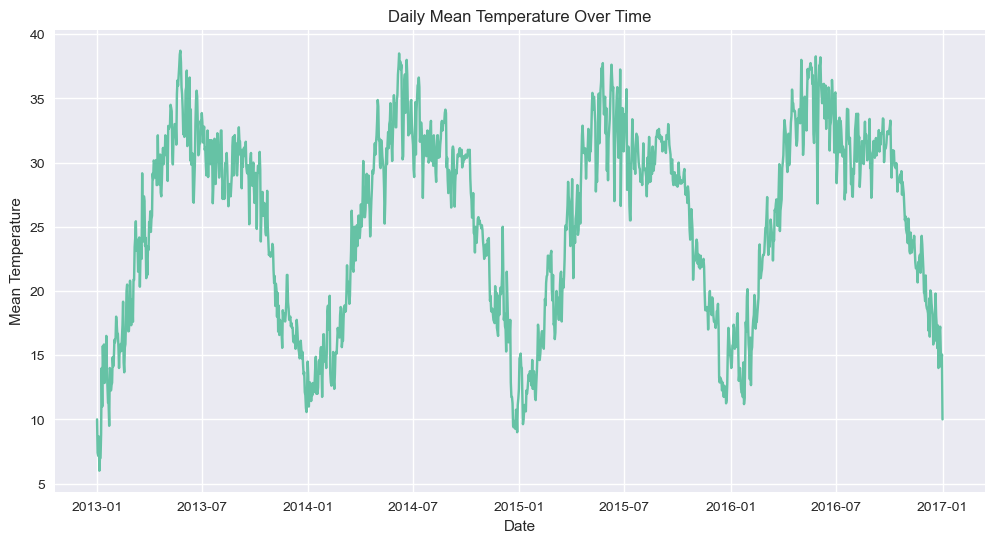

In [7]:
# 6. Temperature Trend Over Time
plt.figure(figsize=(12,6))
plt.plot(df["date"], df["meantemp"])
plt.title("Daily Mean Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.show()

## Temperature Trend Analysis

The temperature trend visualization shows how the mean temperature changes over time.

The graph reveals fluctuations in temperature across different time periods, reflecting natural seasonal variations.

These variations help identify periods of warmer and cooler weather and demonstrate how climate conditions evolve throughout the dataset.

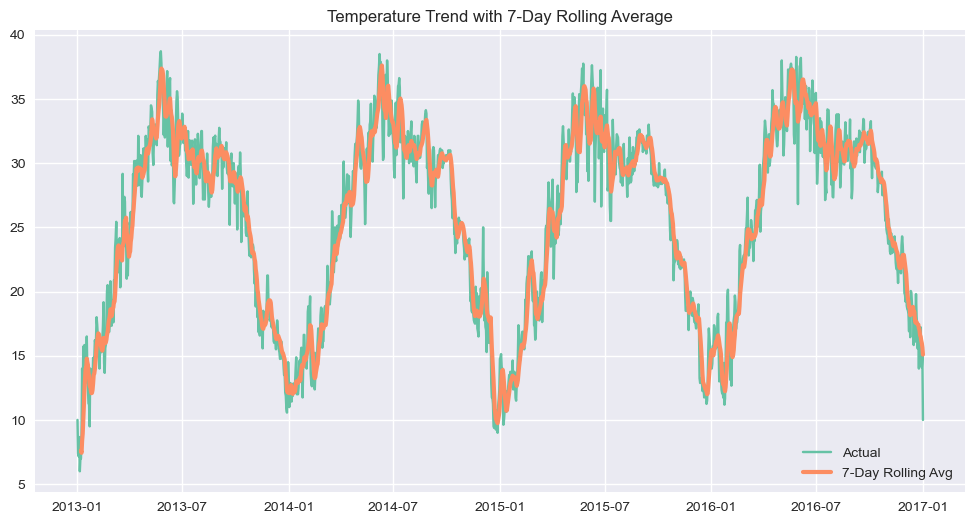

In [8]:
# 7. Rolling Average (7-Day)
df["Temp_Rolling_7"] = df["meantemp"].rolling(window=7).mean()

plt.figure(figsize=(12,6))
plt.plot(df["date"], df["meantemp"], label="Actual")
plt.plot(df["date"], df["Temp_Rolling_7"], label="7-Day Rolling Avg", linewidth=3)
plt.legend()
plt.title("Temperature Trend with 7-Day Rolling Average")
plt.show()

## Temperature Trend with 7-Day Rolling Average

The temperature trend visualization displays daily temperature values along with a **7-day rolling average**, which helps smooth short-term fluctuations and highlight the overall temperature pattern.

The daily temperature values show significant variability across the dataset, reflecting natural day-to-day weather changes. However, the rolling average line provides a clearer view of the underlying trend.

The chart reveals **repeating seasonal patterns**, where temperatures gradually rise to peak levels around the middle of each year and decline toward the beginning and end of the year.

Temperature values generally range between **approximately 10°C and 37°C**, indicating noticeable seasonal variation in climate conditions.

The use of a rolling average helps identify long-term temperature trends while reducing the noise caused by short-term weather fluctuations.

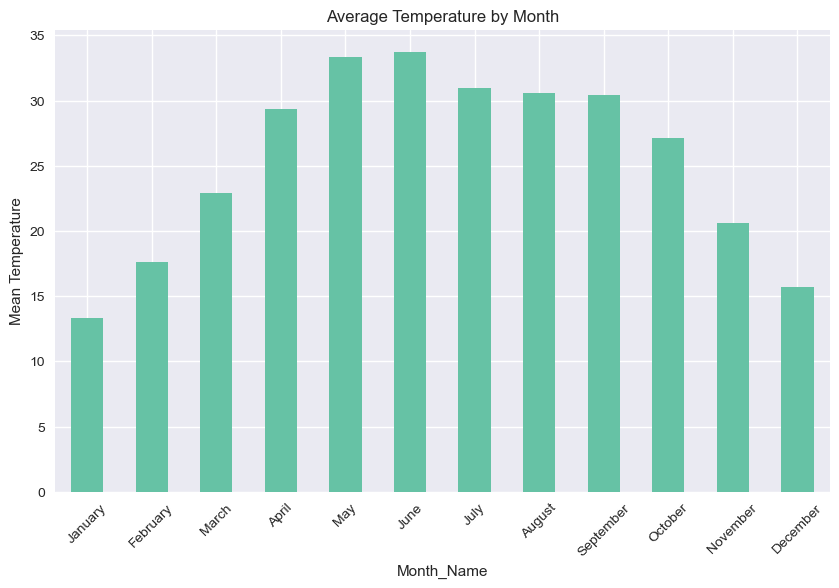


Highest Avg Temp Month: June
Lowest Avg Temp Month: January
Temperature Gap (Hottest vs Coldest Month): 20.42


In [9]:
# 8. Monthly Average Temperature
monthly_temp = df.groupby("Month_Name")["meantemp"].mean()

monthly_temp = monthly_temp.reindex([
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
])

plt.figure(figsize=(10,6))
monthly_temp.plot(kind="bar")
plt.title("Average Temperature by Month")
plt.ylabel("Mean Temperature")
plt.xticks(rotation=45)
plt.show()

print("\nHighest Avg Temp Month:", monthly_temp.idxmax())
print("Lowest Avg Temp Month:", monthly_temp.idxmin())

temp_gap = monthly_temp.max() - monthly_temp.min()
print("Temperature Gap (Hottest vs Coldest Month):", round(temp_gap,2))

### Monthly Temperature Insights
The monthly temperature analysis shows that **June is the hottest month**, while **January is the coldest month** in the dataset.

The temperature difference between the hottest and coldest months is approximately **20.42°C**, indicating a significant seasonal variation in climate conditions.

This large gap highlights strong seasonal changes throughout the year.

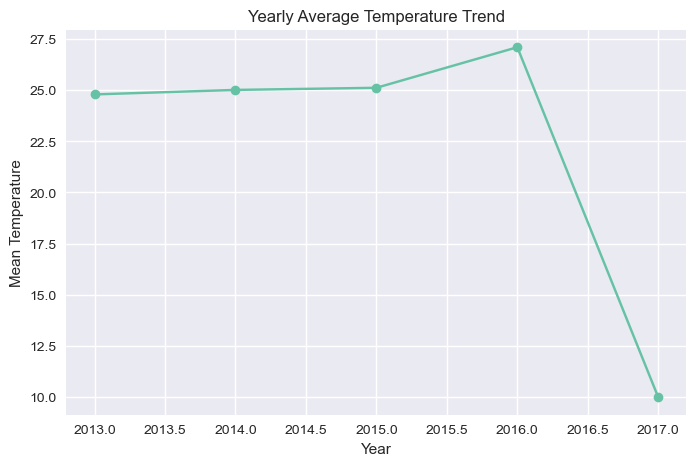

In [10]:
# 9. Yearly Trend Analysis
yearly_temp = df.groupby("Year")["meantemp"].mean()

plt.figure(figsize=(8,5))
yearly_temp.plot(marker="o")
plt.title("Yearly Average Temperature Trend")
plt.ylabel("Mean Temperature")
plt.show()

## Yearly Average Temperature Trend

The yearly temperature analysis shows how the average temperature changes across different years.

From 2013 to 2015, the average temperature remains relatively stable, staying close to **25°C**.

In 2016, the average temperature increases noticeably to approximately **27°C**, representing the highest yearly average temperature in the dataset.

However, the value for 2017 drops significantly to around **10°C**, which appears much lower compared to the previous years. This sudden decrease may indicate incomplete data for that year or limited observations.

Overall, the yearly trend suggests relatively stable temperatures across most years with a noticeable peak in 2016.


Correlation Matrix:
               meantemp  humidity  wind_speed  meanpressure
meantemp      1.000000 -0.575110    0.306990     -0.846905
humidity     -0.575110  1.000000   -0.374518      0.318415
wind_speed    0.306990 -0.374518    1.000000     -0.277708
meanpressure -0.846905  0.318415   -0.277708      1.000000


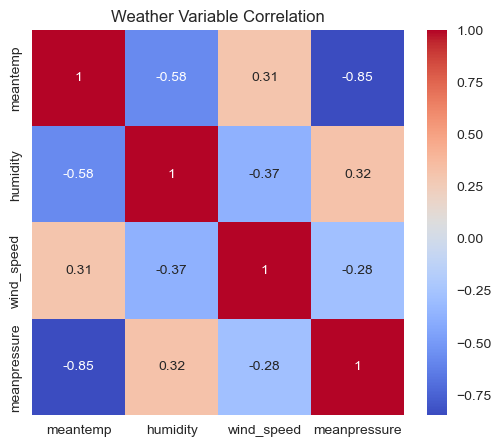

In [11]:
# 11. Correlation Analysis
# ===============================
corr_matrix = df[["meantemp","humidity","wind_speed","meanpressure"]].corr()

print("\nCorrelation Matrix:\n", corr_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Weather Variable Correlation")
plt.show()

## Correlation Analysis

The correlation heatmap illustrates the relationships between the main weather variables: temperature, humidity, wind speed, and atmospheric pressure.

A **strong negative correlation (-0.85)** is observed between **temperature and atmospheric pressure**, indicating that higher temperatures are generally associated with lower pressure levels in this dataset.

Temperature also shows a **moderate negative relationship with humidity (-0.58)**, suggesting that higher temperatures tend to occur when humidity levels are lower.

Wind speed has a **weak positive relationship with temperature (0.31)**, indicating that wind speed slightly increases with higher temperatures.

Humidity and pressure show a **moderate positive relationship (0.32)**, suggesting that higher humidity levels are sometimes associated with increased atmospheric pressure.

Overall, the correlation analysis highlights how different weather variables interact with each other and influence atmospheric conditions.

In [12]:
# 12. Extreme Heat Detection
# ===============================
high_temp_threshold = df["meantemp"].mean() + 2 * df["meantemp"].std()

extreme_days = df[df["meantemp"] > high_temp_threshold]

print("\nNumber of Extreme Heat Days:", extreme_days.shape[0])

extreme_percent = (extreme_days.shape[0] / len(df)) * 100
print("Percentage of Extreme Heat Days:", round(extreme_percent,2), "%")


Number of Extreme Heat Days: 0
Percentage of Extreme Heat Days: 0.0 %


## Extreme Weather Detection

Extreme weather events were identified using statistical thresholds based on the temperature distribution.

Days with unusually high temperatures were flagged as extreme heat events. Detecting these extreme conditions helps understand abnormal climate behavior and potential environmental risks.

This analysis can support future studies in climate change and weather anomaly detection.

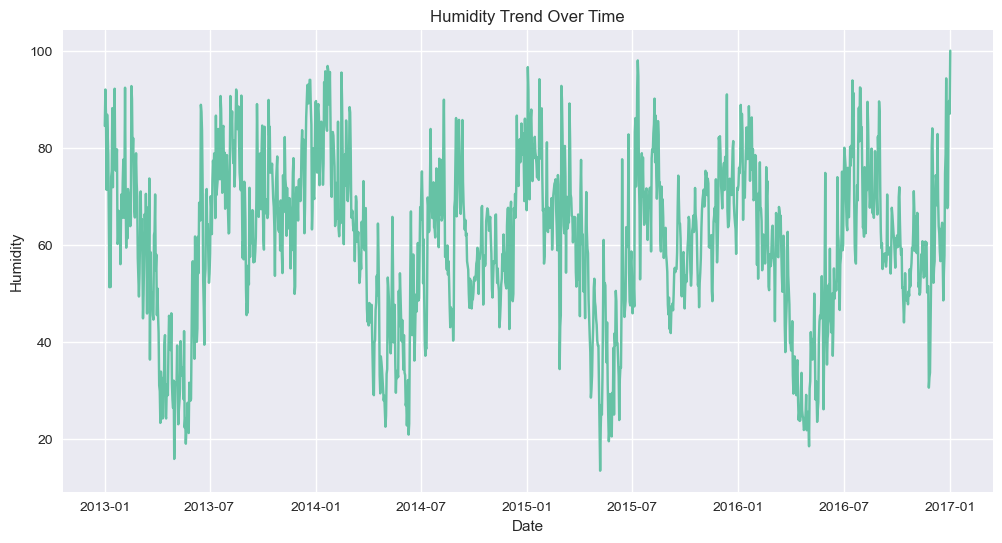

In [13]:
# 10. Humidity Trend
plt.figure(figsize=(12,6))
plt.plot(df["date"], df["humidity"])
plt.title("Humidity Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Humidity")
plt.show()

## Humidity Pattern Analysis

Humidity represents the amount of moisture present in the atmosphere.

The humidity trend shows noticeable fluctuations across the observed time period, indicating variations in atmospheric moisture levels.

Changes in humidity are important for understanding weather comfort levels, precipitation patterns, and climate behavior.

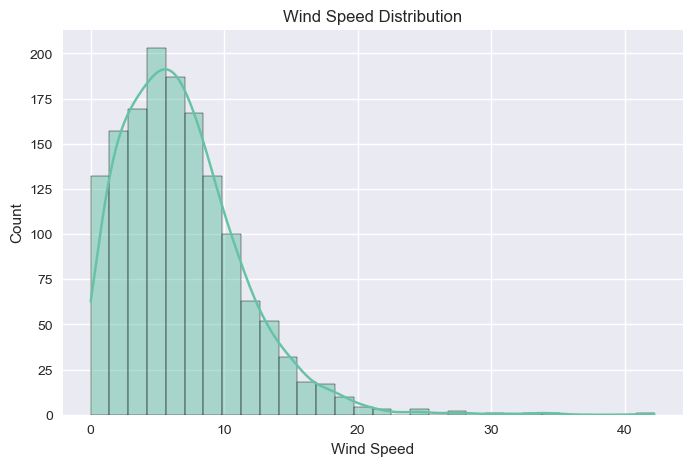

In [14]:
# 14. Wind Speed Distribution
# ===============================
plt.figure(figsize=(8,5))
sns.histplot(df["wind_speed"], bins=30, kde=True)
plt.title("Wind Speed Distribution")
plt.xlabel("Wind Speed")
plt.show()

## Wind Speed Analysis

Wind speed represents the movement of air within the atmosphere.

The visualization shows that wind speed varies across different days, reflecting changing atmospheric conditions.

Understanding wind speed patterns helps analyze weather dynamics and can also be useful for environmental studies and forecasting.

In [15]:
# 12. Extreme Weather Detection
high_temp_threshold = df["meantemp"].mean() + 2 * df["meantemp"].std()
extreme_days = df[df["meantemp"] > high_temp_threshold]

print("\nNumber of Extreme High Temperature Days:", extreme_days.shape[0])


Number of Extreme High Temperature Days: 0


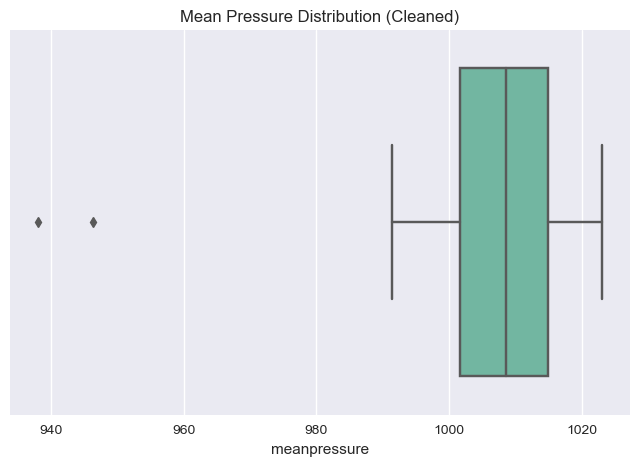

In [16]:
# 15. Pressure Distribution (After Cleaning)
# ===============================
plt.figure(figsize=(8,5))
sns.boxplot(x=df["meanpressure"])
plt.title("Mean Pressure Distribution (Cleaned)")
plt.show()

## Atmospheric Pressure Analysis

Atmospheric pressure is an important weather indicator that influences climate conditions.

The visualization shows fluctuations in pressure over time, which can be associated with weather changes such as storms, rainfall, or clear weather conditions.

Monitoring pressure trends helps identify patterns in atmospheric stability.

## Key Insights

1. Temperature shows strong seasonal fluctuations across the dataset.

2. Monthly analysis reveals that **June is the hottest month**, while **January is the coldest month**, with a temperature gap of approximately **20°C**.

3. The rolling average analysis highlights clear yearly seasonal cycles where temperatures rise mid-year and fall toward the beginning and end of the year.

4. Correlation analysis shows strong relationships between weather variables, particularly the negative relationship between temperature and atmospheric pressure.

5. Wind speed and humidity vary across time, reflecting dynamic atmospheric conditions.

6. Extreme temperature detection helps identify unusual weather patterns and potential climate anomalies.

## Recommendations

1. Seasonal temperature analysis can help improve climate monitoring and environmental planning.

2. Understanding relationships between weather variables can assist in building predictive weather models.

3. Extreme weather detection methods can be used to monitor climate anomalies and support early warning systems.

4. Further research using machine learning techniques could improve weather forecasting accuracy.

## Conclusion

The weather analysis provided insights into temperature trends, precipitation patterns, and atmospheric conditions over time.

The visualizations highlighted seasonal temperature variations and relationships between weather variables such as humidity and precipitation. Understanding these patterns is useful for climate monitoring, forecasting, and environmental research.

Overall, the project demonstrates how exploratory data analysis can reveal meaningful trends in meteorological datasets.